# SVM Multi-Class Classification — Skin Cancer (HAM10000 Metadata)
7 classes: `nv, mel, bkl, bcc, akiec, vasc, df` encoded via `LabelEncoder`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../prepare_data'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    f1_score, balanced_accuracy_score,
)

from preprocess import (
    load_data, filter_valid_dx, make_multiclass_label,
    build_full_pipeline, group_split, grid_search_tune_v2,
    RAW_FEATURES,
)

## 1. Load & EDA

In [2]:
df = load_data('../data/HAM10000_metadata.csv')
df = filter_valid_dx(df)
print(df.shape)
print(df['dx'].value_counts())
df.info()

(10015, 8)
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
 7   dataset       10015 non-null  str    
dtypes: float64(1), str(7)
memory usage: 626.1 KB


In [3]:
print('Missing values:')
print(df.isna().sum())

Missing values:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dataset          0
dtype: int64


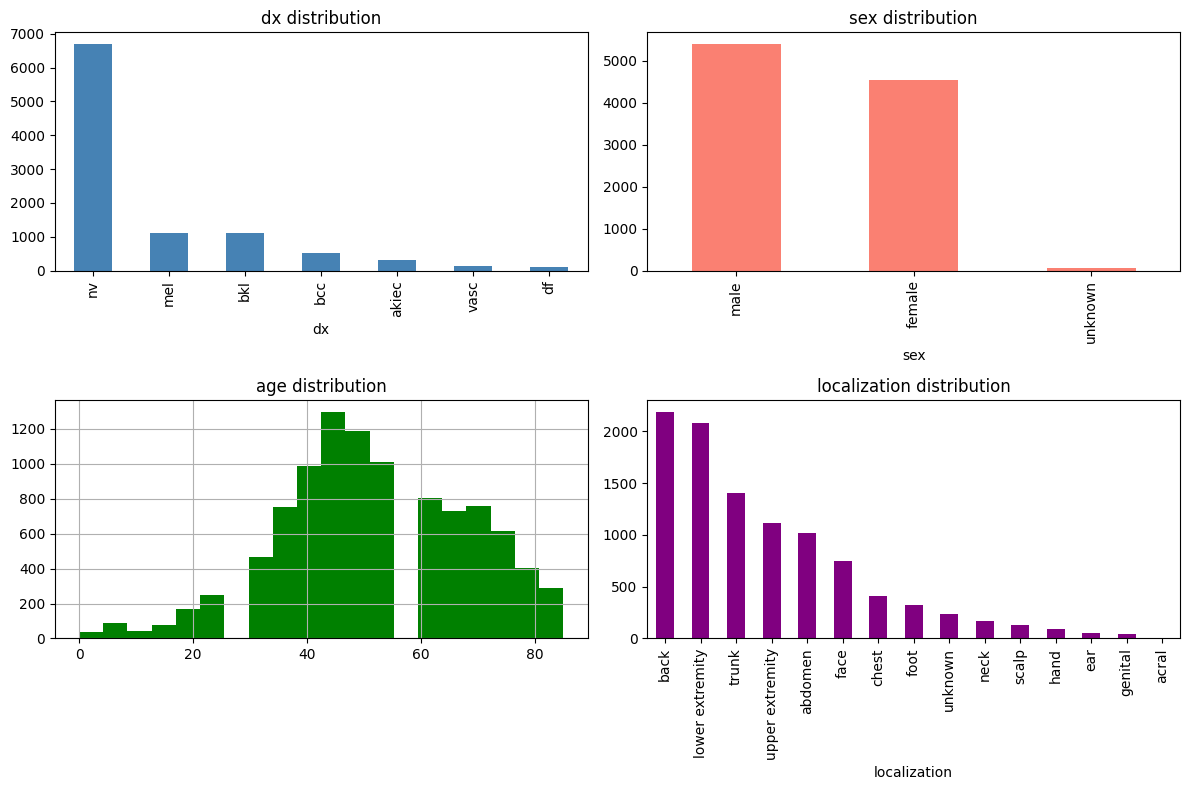

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
df['dx'].value_counts().plot(kind='bar', ax=axes[0,0], title='dx distribution', color='steelblue')
df['sex'].value_counts().plot(kind='bar', ax=axes[0,1], title='sex distribution', color='salmon')
df['age'].hist(ax=axes[1,0], bins=20, color='green')
axes[1,0].set_title('age distribution')
df['localization'].value_counts().plot(kind='bar', ax=axes[1,1], title='localization distribution', color='purple')
plt.tight_layout()
plt.show()

## 2. Preprocessing

In [5]:
df, le_dx = make_multiclass_label(df)
print('Classes:', list(le_dx.classes_))
print('Label distribution:')
print(df['diagnosis'].value_counts().sort_index())

# Keep lesion_id for group split. Drop unused cols only.
df = df[['lesion_id', 'age', 'sex', 'localization', 'diagnosis']]
df.head()

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Label distribution:
diagnosis
0     327
1     514
2    1099
3     115
4    1113
5    6705
6     142
Name: count, dtype: int64


,lesion_id,age,sex,localization,diagnosis
0,HAM_0000118,80.0,male,scalp,2
1,HAM_0000118,80.0,male,scalp,2
2,HAM_0002730,80.0,male,scalp,2
3,HAM_0002730,80.0,male,scalp,2
4,HAM_0001466,75.0,male,ear,2


## 3. Group-Aware Train/Test Split
Split by `lesion_id` — same lesion never crosses train/test.

In [6]:
df_train, df_test = group_split(df, target_col='diagnosis', group_col='lesion_id')

X_train = df_train[RAW_FEATURES]
y_train = df_train['diagnosis'].values
groups_train = df_train['lesion_id'].values

X_test  = df_test[RAW_FEATURES]
y_test  = df_test['diagnosis'].values

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Lesion overlap: {len(set(df_train["lesion_id"]) & set(df_test["lesion_id"]))}')
print(f'Train class balance: {dict(zip(*np.unique(y_train, return_counts=True)))}')

Train: (7991, 3), Test: (2024, 3)
Lesion overlap: 0
Train class balance: {np.int64(0): np.int64(260), np.int64(1): np.int64(424), np.int64(2): np.int64(856), np.int64(3): np.int64(97), np.int64(4): np.int64(877), np.int64(5): np.int64(5369), np.int64(6): np.int64(108)}


## 4. Hyperparameter Tuning — StratifiedGroupKFold + GridSearchCV
- Scoring: `f1_macro` — equal weight per class, not skewed by majority `nv`.
- CV: 5-fold StratifiedGroupKFold by `lesion_id`.
- Single imbalance strategy: SVC `class_weight='balanced'` (no undersampler — old setup collapsed `nv` 5364 → 92 → catastrophic underfit).

In [7]:
gs = grid_search_tune_v2(X_train, y_train, groups=groups_train,
                          scoring='f1_macro', n_splits=5)
print('Best params:', gs.best_params_)
print(f'Best CV f1_macro: {gs.best_score_:.4f}')

cv_results = pd.DataFrame(gs.cv_results_)
top5 = cv_results.sort_values('mean_test_score', ascending=False).head(5)
print(top5[['param_svc__C','param_svc__gamma','param_svc__kernel','mean_test_score','std_test_score']])

Fitting 5 folds for each of 16 candidates, totalling 80 fits


Best params: {'svc__C': 100, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Best CV f1_macro: 0.2017
    param_svc__C param_svc__gamma param_svc__kernel  mean_test_score  \
12         100.0            scale               rbf         0.201734   
8           10.0            scale               rbf         0.198412   
4            1.0            scale               rbf         0.191991   
3            0.1              0.1               rbf         0.189854   
0            0.1            scale               rbf         0.189753   

    std_test_score  
12        0.010450  
8         0.005069  
4         0.008669  
3         0.009285  
0         0.006148  


## 5. Evaluation

In [8]:
best_pipeline = gs.best_estimator_
y_pred = best_pipeline.predict(X_test)

cv_score      = gs.best_score_
test_acc      = accuracy_score(y_test, y_pred)
test_bal_acc  = balanced_accuracy_score(y_test, y_pred)
test_f1_macro = f1_score(y_test, y_pred, average='macro')
test_f1_wt    = f1_score(y_test, y_pred, average='weighted')

print(f'CV f1_macro (mean):  {cv_score:.4f}')
print(f'Test f1_macro:       {test_f1_macro:.4f}')
print(f'Gap (CV - test):     {abs(cv_score - test_f1_macro):.4f}')
print(f'Test accuracy:       {test_acc:.4f}')
print(f'Test balanced acc:   {test_bal_acc:.4f}')
print(f'Test f1_weighted:    {test_f1_wt:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=le_dx.classes_, zero_division=0))

CV f1_macro (mean):  0.2017
Test f1_macro:       0.2163
Gap (CV - test):     0.0145
Test accuracy:       0.3473
Test balanced acc:   0.3453
Test f1_weighted:    0.4319

              precision    recall  f1-score   support

       akiec       0.15      0.60      0.24        67
         bcc       0.14      0.33      0.20        90
         bkl       0.27      0.18      0.22       243
          df       0.02      0.44      0.04        18
         mel       0.22      0.17      0.19       236
          nv       0.91      0.40      0.55      1336
        vasc       0.04      0.29      0.07        34

    accuracy                           0.35      2024
   macro avg       0.25      0.35      0.22      2024
weighted avg       0.67      0.35      0.43      2024



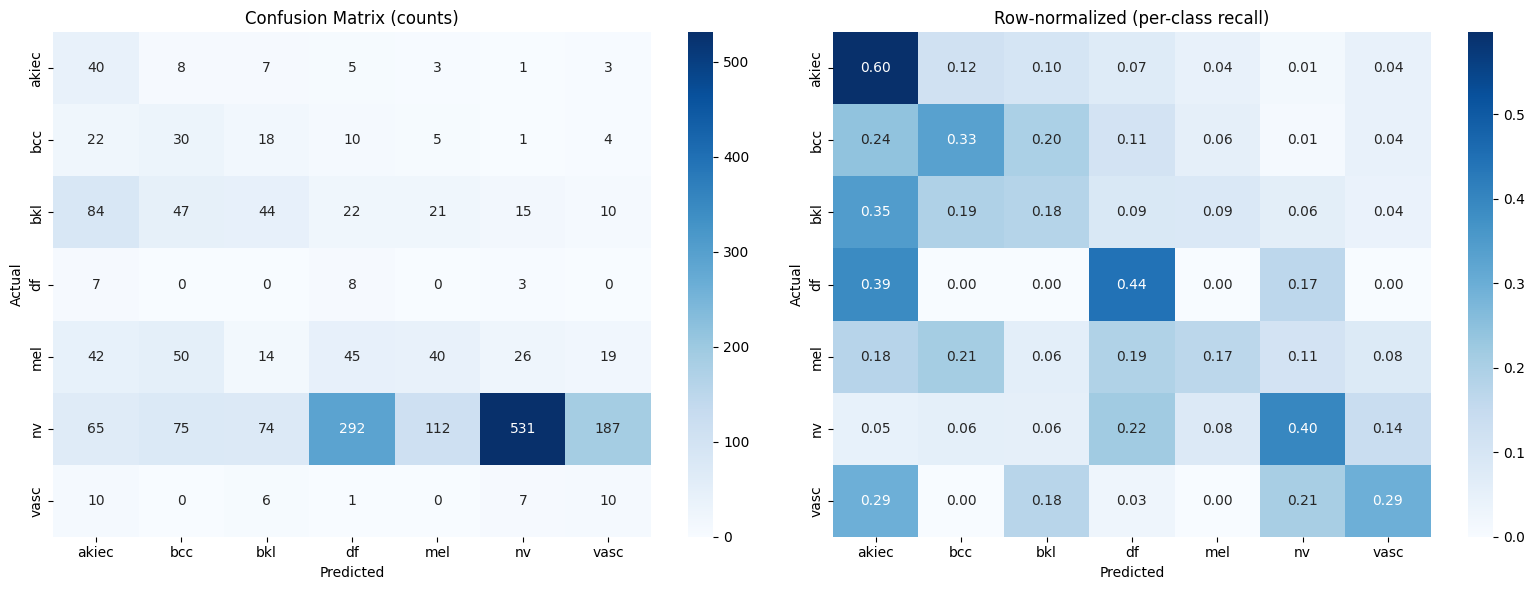

In [9]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_dx.classes_, yticklabels=le_dx.classes_, ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (counts)')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le_dx.classes_, yticklabels=le_dx.classes_, ax=axes[1])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].set_title('Row-normalized (per-class recall)')

plt.tight_layout()
plt.show()

## 6. Save Model

In [10]:
os.makedirs('../model', exist_ok=True)
bundle = {
    'pipeline':  best_pipeline,    # expects DataFrame[age, sex, localization]
    'features':  RAW_FEATURES,
    'le_dx':     le_dx,            # for inverse_transform at inference
    'raw_input': True,
}
joblib.dump(bundle, '../model/svm_multi_class_model.joblib')
print('Saved: ../model/svm_multi_class_model.joblib')

Saved: ../model/svm_multi_class_model.joblib
